# Phase 1 (IHDS-II) — Data Understanding

[`walkthrough/ihds_phase1.md`](../walkthrough/ihds_phase1.md)

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

DATA_PATH = "../dataset/ihds2_households.csv"
df = pd.read_csv(DATA_PATH)

EXPENSE_CATEGORIES = [
    "Groceries", "Eating_Out", "Utilities", "Rent", "Transport", "Healthcare",
    "Education", "Entertainment", "Insurance", "Clothing_Footwear", "Miscellaneous",
]
SHARE_COLS = [f"{c}_Share" for c in EXPENSE_CATEGORIES]
BEHAVIOUR_COLS = [c for c in df.columns if c.startswith("Has_")]
ID_COLS = ["STATEID", "DISTID", "PSUID", "HHID", "HHSPLITID", "IDHH"]
LEAKAGE_COLS = EXPENSE_CATEGORIES + ["COTOTAL", "Savings", "Savings_Rate"]

print(f"Shape: {df.shape}")
print(f"Households: {len(df):,}")

Shape: (41518, 50)
Households: 41,518


## Q1 — What does each column mean, and what unit/time period does it represent?

In [2]:
roles = []
for c in df.columns:
    if c in ID_COLS:
        role, unit = "Identifier", "survey code"
    elif c == "WT":
        role, unit = "Survey weight", "design weight (unapplied)"
    elif c in LEAKAGE_COLS:
        role, unit = "LEAKAGE - excluded", "annual Rs" if c != "Savings_Rate" else "proportion"
    elif c == "Goal_Met":
        role, unit = "TARGET", "binary"
    elif c in BEHAVIOUR_COLS:
        role, unit = "External validation - excluded", "binary"
    elif c in SHARE_COLS:
        role, unit = "Feature", "share of total expenditure"
    elif c in ("INCOME",):
        role, unit = "Feature", "annual Rs"
    elif c == "Log_Income":
        role, unit = "Feature", "log annual Rs"
    elif df[c].dtype == object:
        role, unit = "Feature", "categorical"
    else:
        role, unit = "Feature", "count / ratio"
    roles.append({"column": c, "role": role, "unit": unit, "dtype": str(df[c].dtype)})

inventory = pd.DataFrame(roles)
print(inventory.groupby("role").size().to_string())
print()
print(inventory.to_string(index=False))

role
External validation - excluded     6
Feature                           22
Identifier                         6
LEAKAGE - excluded                14
Survey weight                      1
TARGET                             1

                 column                           role                       unit   dtype
                STATEID                     Identifier                survey code   int64
                 DISTID                     Identifier                survey code   int64
                  PSUID                     Identifier                survey code   int64
                   HHID                     Identifier                survey code   int64
              HHSPLITID                     Identifier                survey code   int64
                   IDHH                     Identifier                survey code   int64
                     WT                  Survey weight  design weight (unapplied) float64
                 INCOME                        Featu

## Q2 — Distribution of income, expenses, and savings: skew, outliers, implausible values

In [3]:
money = ["INCOME", "COTOTAL", "Savings"] + EXPENSE_CATEGORIES
desc = df[money].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
desc["skew"] = df[money].skew()
print("Money columns (annual Rs):")
print(desc.round(1).to_string())

print("\nSavings rate:")
print(df["Savings_Rate"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(4).to_string())

Money columns (annual Rs):
                       mean       std        min      25%      50%       75%         max   skew
INCOME             129977.4  217306.4      100.0  40230.0  75000.0  145717.5  11360000.0   15.8
COTOTAL            117938.8  120992.8      180.0  56251.0  87175.0  139984.5   4080760.0    7.2
Savings             12038.6  196600.3 -4000836.0 -38619.8  -6487.0   33367.0  11083796.0   15.4
Groceries           44770.5   26549.4        0.0  27360.0  39612.0   55716.0    764880.0    2.6
Eating_Out           1141.3    3772.4        0.0      0.0      0.0     720.0    240000.0   14.8
Utilities           10209.8   14095.3        0.0   4896.0   8376.0   12852.0   1079016.0   48.0
Rent                 1530.0   10124.1        0.0      0.0      0.0       0.0    720000.0   24.3
Transport           10016.1   25966.9        0.0   1200.0   3600.0   10800.0   1228800.0   17.8
Healthcare          12125.4   38845.1        0.0    822.5   3600.0   11200.0   4001800.0   35.4
Education    

In [4]:
print("=== Implausible / structurally awkward values ===")
n = len(df)
checks = {
    "consumption exceeds income (negative savings)": (df["Savings"] < 0),
    "savings rate below -100% (spends >2x income)": (df["Savings_Rate"] < -1),
    "savings rate below -500%": (df["Savings_Rate"] < -5),
    "zero rent recorded": (df["Rent"] == 0),
    "zero education spend": (df["Education"] == 0),
    "zero insurance spend": (df["Insurance"] == 0),
    "head age below 18": (df["Head_Age"] < 18),
    "debt exceeds 10x annual income": (df["Debt_To_Income"] > 10),
}
for label, mask in checks.items():
    print(f"  {label:46s} {mask.sum():6,}  ({mask.mean():6.2%})")

print("\n=== Zero-inflation in the share features ===")
zero = (df[SHARE_COLS] == 0).mean().sort_values(ascending=False)
print(zero.round(4).to_string())

print("\n=== Debt_To_Income tail ===")
print(df["Debt_To_Income"].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]).round(3).to_string())

=== Implausible / structurally awkward values ===
  consumption exceeds income (negative savings)  23,204  (55.89%)
  savings rate below -100% (spends >2x income)    9,137  (22.01%)
  savings rate below -500%                        1,635  ( 3.94%)
  zero rent recorded                             37,553  (90.45%)
  zero education spend                           14,906  (35.90%)
  zero insurance spend                           30,587  (73.67%)
  head age below 18                                  14  ( 0.03%)
  debt exceeds 10x annual income                    430  ( 1.04%)

=== Zero-inflation in the share features ===
Rent_Share                 0.9045
Insurance_Share            0.7367
Eating_Out_Share           0.7196
Entertainment_Share        0.6912
Education_Share            0.3590
Healthcare_Share           0.1915
Transport_Share            0.1141
Clothing_Footwear_Share    0.0139
Utilities_Share            0.0016
Miscellaneous_Share        0.0007
Groceries_Share            0.0006

=

## Q3 — Missing values and duplicate rows

In [5]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(pd.DataFrame({"n_missing": miss, "pct": (miss / len(df) * 100).round(3)}).to_string()
      if len(miss) else "  (none)")

print("\nDuplicate household identifiers:", df["IDHH"].duplicated().sum())
print("Fully duplicated rows:", df.duplicated().sum())

print("\nSample construction (from src/build_ihds_dataset.py):")
print("  raw IHDS DS0002 households        42,152")
print(f"  dropped: INCOME <= 0 or COTOTAL missing/zero   {42152 - len(df):,}")
print(f"  retained                          {len(df):,}")

Columns with missing values:
                         n_missing    pct
Has_Gold_Jewellery             176  0.424
Has_Pension_LIC                155  0.373
Has_Post_Office_Account        142  0.342
Has_Fixed_Deposit              138  0.332
Has_Securities                 133  0.320
Has_Bank_Savings               133  0.320
Caste_Group                     85  0.205
Religion                        12  0.029
Max_Adult_Education              6  0.014

Duplicate household identifiers: 0
Fully duplicated rows: 0

Sample construction (from src/build_ihds_dataset.py):
  raw IHDS DS0002 households        42,152
  dropped: INCOME <= 0 or COTOTAL missing/zero   634
  retained                          41,518


## Q4 — How correlated are expense categories with income and with each other?

In [6]:
print("=== Raw rupee categories vs INCOME (the LEAKY representation) ===")
raw_corr = df[EXPENSE_CATEGORIES].corrwith(df["INCOME"]).sort_values(ascending=False)
print(raw_corr.round(4).to_string())
print(f"\nmean |r| between raw categories: "
      f"{df[EXPENSE_CATEGORIES].corr().where(~np.eye(11, dtype=bool)).abs().stack().mean():.4f}")

print("\n=== Composition shares vs Log_Income (the MODELLED representation) ===")
share_corr = df[SHARE_COLS].corrwith(df["Log_Income"]).sort_values()
print(share_corr.round(4).to_string())

=== Raw rupee categories vs INCOME (the LEAKY representation) ===
Groceries            0.4281
Transport            0.3087
Insurance            0.2935
Utilities            0.2685
Eating_Out           0.2304
Education            0.2228
Entertainment        0.2085
Miscellaneous        0.2008
Clothing_Footwear    0.1847
Healthcare           0.1055
Rent                 0.0875

mean |r| between raw categories: 0.1428

=== Composition shares vs Log_Income (the MODELLED representation) ===
Groceries_Share           -0.2660
Healthcare_Share          -0.1275
Utilities_Share           -0.0649
Clothing_Footwear_Share   -0.0238
Miscellaneous_Share        0.0593
Rent_Share                 0.0796
Eating_Out_Share           0.1171
Entertainment_Share        0.1542
Education_Share            0.1794
Insurance_Share            0.2505
Transport_Share            0.2729


=== Correlation structure among the shares (compositional closure) ===
  mean off-diagonal correlation: -0.0638
  share of pairs that are negative: 65.45%
  most negative pair: ('Groceries_Share', 'Healthcare_Share') = -0.3621
  most positive pair: ('Eating_Out_Share', 'Entertainment_Share') = +0.1097


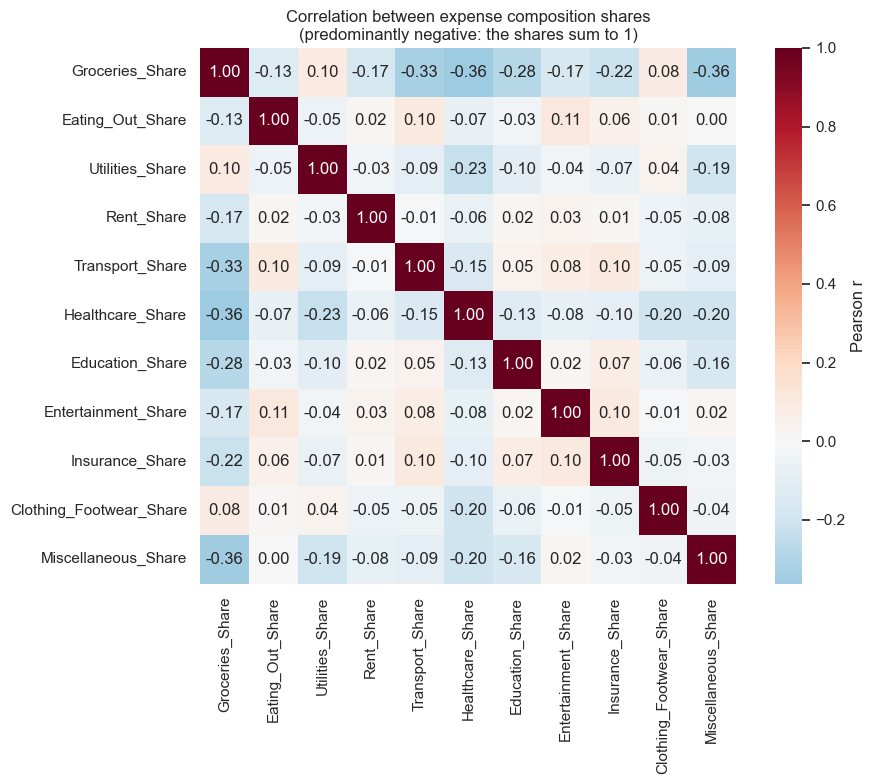

In [7]:
share_cm = df[SHARE_COLS].corr()
off_diag = share_cm.where(~np.eye(len(SHARE_COLS), dtype=bool)).stack()
print("=== Correlation structure among the shares (compositional closure) ===")
print(f"  mean off-diagonal correlation: {off_diag.mean():+.4f}")
print(f"  share of pairs that are negative: {(off_diag < 0).mean():.2%}")
print(f"  most negative pair: {off_diag.idxmin()} = {off_diag.min():+.4f}")
print(f"  most positive pair: {off_diag.idxmax()} = {off_diag.max():+.4f}")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(share_cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation between expense composition shares\n(predominantly negative: the shares sum to 1)")
plt.tight_layout()
plt.savefig("../results/ihds_phase1_share_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## Q5 — Leakage check: is the target mathematically derivable from any candidate feature?

In [8]:
print("=== Identity 1: does Savings = INCOME - COTOTAL exactly? ===")
err = (df["Savings"] - (df["INCOME"] - df["COTOTAL"])).abs().max()
print(f"  max absolute error: {err:.3e}")

print("\n=== Identity 2: does COTOTAL equal the sum of the 11 categories? ===")
err2 = (df["COTOTAL"] - df[EXPENSE_CATEGORIES].sum(axis=1)).abs()
print(f"  max abs error: {err2.max():,.1f}   median: {err2.median():,.1f}")
print(f"  within 1% of COTOTAL: {((err2 / df['COTOTAL']) < 0.01).mean():.4f}")

print("\n=== Leakage test A: raw categories + INCOME reconstruct the target? ===")
implied_raw = ((df["INCOME"] - df[EXPENSE_CATEGORIES].sum(axis=1)) / df["INCOME"] >= 0.20).astype(int)
print(f"  agreement with Goal_Met: {(implied_raw == df['Goal_Met']).mean():.6f}   -> EXCLUDE raw categories")

print("\n=== Leakage test B: expense-to-INCOME ratios reconstruct the target? ===")
ratios = df[EXPENSE_CATEGORIES].div(df["INCOME"], axis=0)
implied_ratio = (ratios.sum(axis=1) <= 0.80).astype(int)
print(f"  agreement with Goal_Met: {(implied_ratio == df['Goal_Met']).mean():.6f}   -> EXCLUDE income ratios")

print("\n=== Leakage test C: composition shares reconstruct the target? ===")
print(f"  shares sum to: min={df[SHARE_COLS].sum(axis=1).min():.6f} "
      f"max={df[SHARE_COLS].sum(axis=1).max():.6f}")
print("  a constant sum carries no information about COTOTAL/INCOME, so no reconstruction is possible")
print(f"  max |correlation| of any share with Savings_Rate: "
      f"{df[SHARE_COLS].corrwith(df['Savings_Rate']).abs().max():.4f}")

print("\n=== Leakage test D: the behavioural Has_* columns ===")
print("  survey-reported behaviour, NOT part of the target arithmetic - reserved for")
print("  external validation only, never used as features:")
print(df[BEHAVIOUR_COLS].mean().round(4).to_string())

=== Identity 1: does Savings = INCOME - COTOTAL exactly? ===
  max absolute error: 5.821e-11

=== Identity 2: does COTOTAL equal the sum of the 11 categories? ===
  max abs error: 960,000.0   median: 0.0
  within 1% of COTOTAL: 0.9772

=== Leakage test A: raw categories + INCOME reconstruct the target? ===
  agreement with Goal_Met: 0.997471   -> EXCLUDE raw categories

=== Leakage test B: expense-to-INCOME ratios reconstruct the target? ===
  agreement with Goal_Met: 0.997471   -> EXCLUDE income ratios

=== Leakage test C: composition shares reconstruct the target? ===
  shares sum to: min=1.000000 max=1.000000
  a constant sum carries no information about COTOTAL/INCOME, so no reconstruction is possible
  max |correlation| of any share with Savings_Rate: 0.0559

=== Leakage test D: the behavioural Has_* columns ===
  survey-reported behaviour, NOT part of the target arithmetic - reserved for
  external validation only, never used as features:
Has_Securities             0.0160
Has_Fix

## Q6 — Class balance once leakage columns are excluded

In [9]:
print("=== Class balance at the 20% benchmark ===")
vc = df["Goal_Met"].value_counts().sort_index()
print(pd.DataFrame({"n": vc, "pct": (vc / len(df) * 100).round(2)}).to_string())
print(f"\nimbalance ratio: {vc.max() / vc.min():.2f} : 1")

print("\n=== Sensitivity to the (arbitrary) threshold ===")
rows = []
for t in [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40]:
    g = (df["Savings_Rate"] >= t).astype(int)
    rows.append({"threshold": f"{t:.0%}", "Goal_Met rate": g.mean(),
                 "n_met": int(g.sum()), "imbalance": max(g.mean(), 1 - g.mean()) / min(g.mean(), 1 - g.mean())})
print(pd.DataFrame(rows).round(4).to_string(index=False))

print("\n=== Survey-weighted vs unweighted ===")
w = df["WT"]
print(f"  unweighted Goal_Met rate: {df['Goal_Met'].mean():.4f}")
print(f"  weighted Goal_Met rate:   {np.average(df['Goal_Met'], weights=w):.4f}")

print("\n=== Goal_Met by area type ===")
print(df.groupby("Area_Type")["Goal_Met"].agg(["mean", "count"]).sort_values("mean", ascending=False).round(4).to_string())

print("\n=== Goal_Met by occupation ===")
print(df.groupby("Occupation")["Goal_Met"].agg(["mean", "count"]).sort_values("mean", ascending=False).round(4).to_string())

=== Class balance at the 20% benchmark ===
              n    pct
Goal_Met              
0         28262  68.07
1         13256  31.93

imbalance ratio: 2.13 : 1

=== Sensitivity to the (arbitrary) threshold ===
threshold  Goal_Met rate  n_met  imbalance
       0%         0.4411  18314     1.2670
       5%         0.4138  17182     1.4164
      10%         0.3833  15913     1.6091
      15%         0.3505  14554     1.8527
      20%         0.3193  13256     2.1320
      25%         0.2868  11909     2.4863
      30%         0.2532  10514     2.9488
      40%         0.1876   7790     4.3297

=== Survey-weighted vs unweighted ===
  unweighted Goal_Met rate: 0.3193
  weighted Goal_Met rate:   0.3047

=== Goal_Met by area type ===
                          mean  count
Area_Type                            
Metro_Urban             0.4212   3063
Other_Urban             0.3698  11410
Developed_Village       0.3091  12635
Less_Developed_Village  0.2666  14410

=== Goal_Met by occupation ===
 

## Summary figure

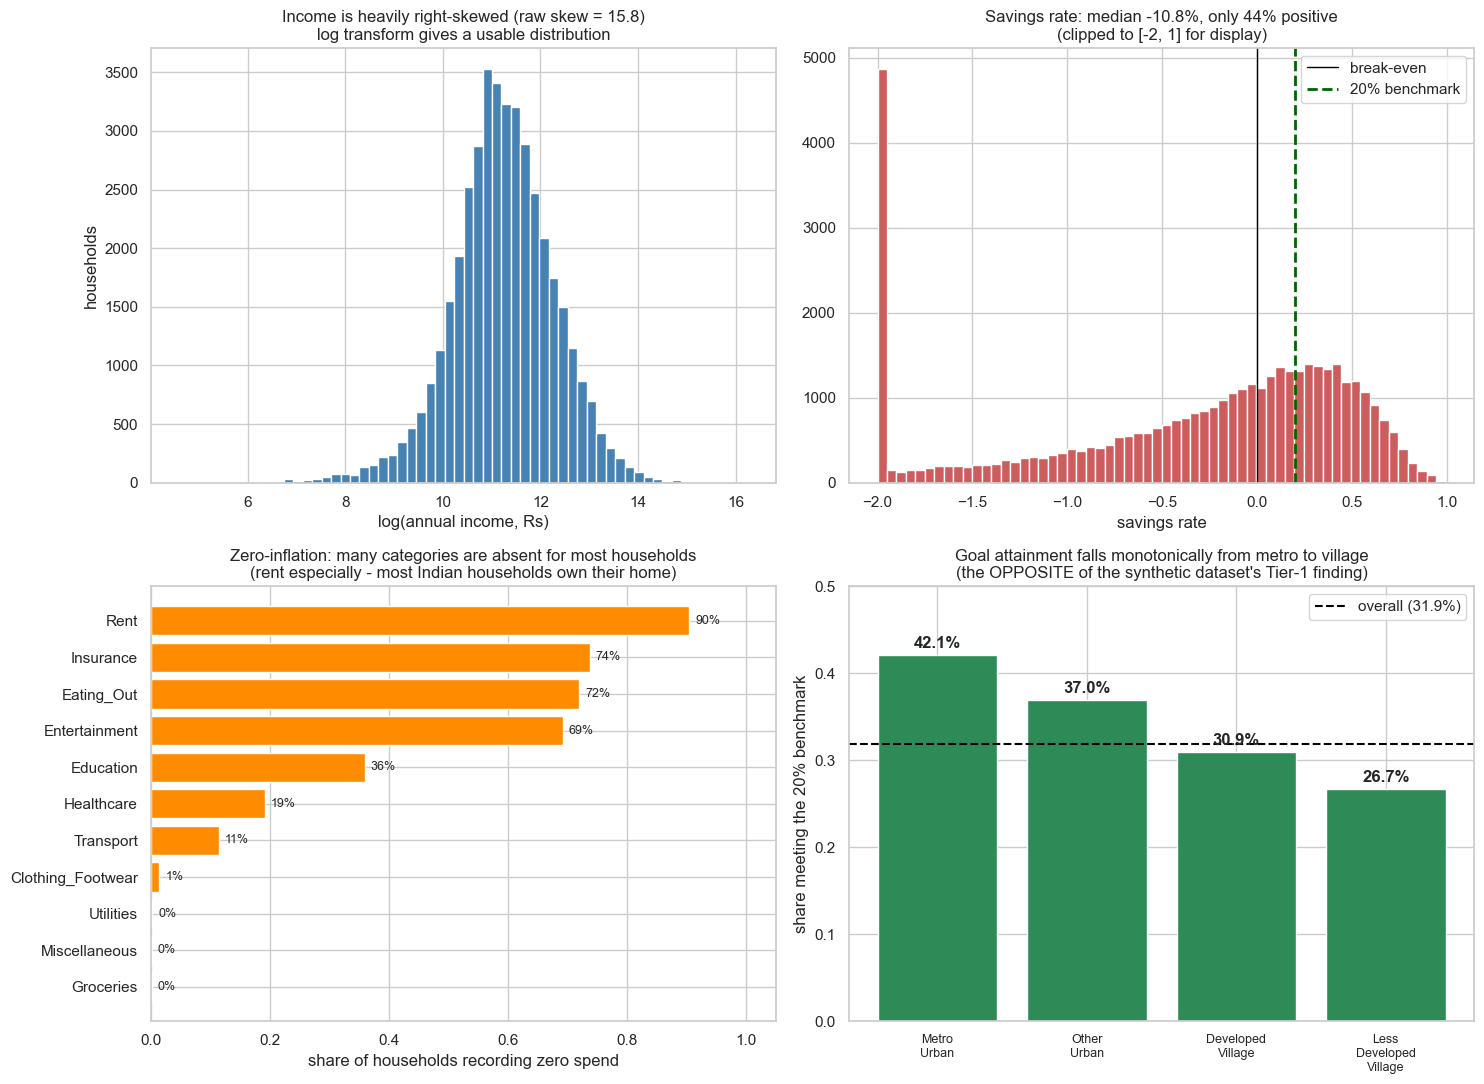

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Income is right-skewed; log fixes it
ax = axes[0, 0]
ax.hist(df["Log_Income"], bins=60, color="steelblue", edgecolor="white")
ax.set_title(f"Income is heavily right-skewed (raw skew = {df['INCOME'].skew():.1f})\n"
             "log transform gives a usable distribution")
ax.set_xlabel("log(annual income, Rs)")
ax.set_ylabel("households")

# 2. Savings rate: most households are negative
ax = axes[0, 1]
clipped = df["Savings_Rate"].clip(-2, 1)
ax.hist(clipped, bins=60, color="indianred", edgecolor="white")
ax.axvline(0, color="black", ls="-", lw=1, label="break-even")
ax.axvline(0.20, color="darkgreen", ls="--", lw=2, label="20% benchmark")
ax.set_title(f"Savings rate: median {df['Savings_Rate'].median():.1%}, "
             f"only {(df['Savings_Rate'] > 0).mean():.0%} positive\n(clipped to [-2, 1] for display)")
ax.set_xlabel("savings rate")
ax.legend()

# 3. Zero-inflation in shares
ax = axes[1, 0]
zero = (df[SHARE_COLS] == 0).mean().sort_values()
ax.barh([c.replace("_Share", "") for c in zero.index], zero.values, color="darkorange")
for i, v in enumerate(zero.values):
    ax.annotate(f"{v:.0%}", (v + 0.01, i), va="center", fontsize=9)
ax.set_xlim(0, 1.05)
ax.set_title("Zero-inflation: many categories are absent for most households\n"
             "(rent especially - most Indian households own their home)")
ax.set_xlabel("share of households recording zero spend")

# 4. Goal_Met by area type
ax = axes[1, 1]
order = ["Metro_Urban", "Other_Urban", "Developed_Village", "Less_Developed_Village"]
rate = df.groupby("Area_Type")["Goal_Met"].mean().reindex(order)
ax.bar(range(4), rate.values, color="seagreen")
ax.axhline(df["Goal_Met"].mean(), color="black", ls="--", label=f"overall ({df['Goal_Met'].mean():.1%})")
ax.set_xticks(range(4))
ax.set_xticklabels([o.replace("_", "\n") for o in order], fontsize=9)
for i, v in enumerate(rate.values):
    ax.annotate(f"{v:.1%}", (i, v + 0.008), ha="center", fontweight="bold")
ax.set_ylim(0, 0.5)
ax.set_title("Goal attainment falls monotonically from metro to village\n"
             "(the OPPOSITE of the synthetic dataset's Tier-1 finding)")
ax.set_ylabel("share meeting the 20% benchmark")
ax.legend()

plt.tight_layout()
plt.savefig("../results/ihds_phase1_eda.png", dpi=150, bbox_inches="tight")
plt.show()